#  Preventing fraud in PIX transactions

## Data preprocessing

### Importing libraries

In [1]:
import sys

import xgboost as xgb
# Statistical analysis
from scipy.stats import mstats
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

sys.path.append('C:/Users/gabri/PycharmProjects/SumUp')  # Add the path to your custom modules
from sanity_functions import *

### Reading .parquet file

In [2]:
raw_transactions = pd.read_parquet('../sumup_case.parquet')
raw_transactions.head()

,event_created_at,amount,infraction,merchant_id,mc_weeks_signup,mc_atm_br_tx_out_count_lifetime,mc_credit_transfer_out_br_sum_last_30d,mc_billpay_br_sum_last_15d,mc_billpay_br_count_last_1y,mc_credit_transfer_out_br_sum_last_1y,...,mc_tx_cp_dbt_sum_sq_fail_last_14d,mc_merchants_ip_count_dist_shared_last_15d,mcc_sum_succ_1y,mcc_sum_sq_succ_30d,mcc_count_succ_1y,mcc_sum_sq_succ_1y,mcc_sum_succ_30d,is_legal_entity,is_mei,is_person
3883,2024-02-02 21:43:57.697,27500,0,DAQQ7TS,322.285714,0.0,411.133179,NaN,0.0,5048.175078,...,0.0000,NaN,7.523910e+08,1.404402e+11,4232421,1.548410e+12,6.384952e+07,0,0,1
3884,2024-02-02 20:49:30.476,280550,0,CR4K9VY,66.285714,0.0,35289.128889,170.986536,13.0,334646.251337,...,423018.1025,NaN,7.412321e+08,9.651831e+10,8401389,2.947039e+12,2.877422e+07,0,0,1
3885,2024-02-02 15:32:12.033,15000,0,DSSEHKE,284.142857,0.0,1585.621610,NaN,0.0,10383.890144,...,0.0000,NaN,2.189377e+09,3.328640e+11,18806623,3.802283e+12,1.733248e+08,0,1,0
3886,2024-02-02 13:21:08.696,17700,0,2C2EP9Y,38.857143,0.0,2659.310168,NaN,46.0,23495.076815,...,5147.0000,NaN,9.638338e+07,4.847552e+09,2114366,6.598435e+10,8.536190e+06,0,0,1
3887,2024-02-02 18:32:29.093,25900,0,C3NYGCP,39.142857,0.0,1663.235351,NaN,14.0,13035.453581,...,0.0000,1.0,2.997443e+09,5.486961e+11,31893920,5.762067e+12,2.198331e+08,0,0,1


In [3]:
raw_transactions.shape
# (1.307.011, 98)

(1307011, 98)

### Understanding our table

In [4]:
caract_df(raw_transactions)

Nº linhas: 1307011
Nº colunas: 98
Nº linhas duplicadas: 315046

Nº de vazios*:
	mc_weeks_signup: 20609 - 1.58%
	mc_atm_br_tx_out_count_lifetime: 5021 - 0.38%
	mc_credit_transfer_out_br_sum_last_30d: 35489 - 2.72%
	mc_billpay_br_sum_last_15d: 905982 - 69.32%
	mc_billpay_br_count_last_1y: 5071 - 0.39%
	mc_credit_transfer_out_br_sum_last_1y: 15724 - 1.2%
	mc_billpay_br_count_sanction_last_30d: 11689 - 0.89%
	mc_pur_br_count_last_1y: 5071 - 0.39%
	mc_billpay_br_count_last_15d: 20778 - 1.59%
	mc_atm_br_tx_out_count_last_1y: 5071 - 0.39%
	mc_sanction_count_last_2d: 267029 - 20.43%
	mc_pur_br_sum_last_15d: 911851 - 69.77%
	mc_credit_transfer_in_br_sum_last_180d: 14463 - 1.11%
	mc_credit_transfer_out_br_count_lifetime: 5021 - 0.38%
	mc_credit_transfer_out_br_count_sanction_last_30d: 11689 - 0.89%
	mc_credit_transfer_out_br_count_last_15d: 20778 - 1.59%
	mc_pur_br_count_last_15d: 20778 - 1.59%
	mc_pep_count_last_2d: 267029 - 20.43%
	mc_credit_transfer_in_br_sum_last_120d: 16566 - 1.27%
	mc_pur_

Nº linhas: 1307011
Nº colunas: 98
Nº linhas duplicadas: 315.046

In [5]:
raw_transactions[
    ['mc_billpay_br_sum_last_15d', 'mc_billpay_br_count_last_1y', 'mc_pur_br_sum_last_15d', 'mc_pep_count_last_2d',
     'mc_billpay_br_sum_last_1y', 'mc_pur_br_sum_last_1y', 'mc_merchants_ip_count_dist_shared_last_15d']]

,mc_billpay_br_sum_last_15d,mc_billpay_br_count_last_1y,mc_pur_br_sum_last_15d,mc_pep_count_last_2d,mc_billpay_br_sum_last_1y,mc_pur_br_sum_last_1y,mc_merchants_ip_count_dist_shared_last_15d
3883,NaN,0.0,NaN,NaN,NaN,NaN,NaN
3884,170.986536,13.0,14.034572,0.0,1958.675642,19.623974,NaN
3885,NaN,0.0,NaN,NaN,NaN,NaN,NaN
3886,NaN,46.0,NaN,0.0,2818.537289,NaN,NaN
3887,NaN,14.0,150.098176,0.0,467.753326,2164.794845,1.0
...,...,...,...,...,...,...,...
1032110,NaN,0.0,NaN,0.0,NaN,NaN,NaN
1032111,NaN,1.0,NaN,0.0,100.335200,NaN,1.0
1032112,NaN,38.0,NaN,0.0,1200.632658,28.060891,NaN
1032113,NaN,0.0,NaN,0.0,NaN,NaN,NaN


In [6]:
raw_transactions[
    ['mc_billpay_br_sum_last_15d', 'mc_billpay_br_count_last_1y', 'mc_pur_br_sum_last_15d', 'mc_pep_count_last_2d',
     'mc_billpay_br_sum_last_1y', 'mc_pur_br_sum_last_1y', 'mc_merchants_ip_count_dist_shared_last_15d']].describe().T

,count,mean,std,min,25%,50%,75%,max
mc_billpay_br_sum_last_15d,401029.0,599.289714,2566.797730,0.001830,42.933518,142.665378,445.094419,89807.066260
mc_billpay_br_count_last_1y,1301940.0,22.109803,58.017485,0.000000,0.000000,3.000000,19.000000,1895.000000
mc_pur_br_sum_last_15d,395160.0,120.420719,248.607328,0.001852,7.588960,39.428630,134.707939,8078.591767
mc_pep_count_last_2d,1039982.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
mc_billpay_br_sum_last_1y,824537.0,4026.541504,17086.059676,0.001801,169.224707,732.670949,2783.073379,580341.045409
mc_pur_br_sum_last_1y,759459.0,1316.364392,2897.544228,0.001823,46.232696,307.854926,1389.647388,63840.503002
mc_merchants_ip_count_dist_shared_last_15d,259304.0,42.742626,182.286831,1.000000,1.000000,2.000000,3.000000,4735.000000


In [7]:
data_info = pd.concat([pd.DataFrame(raw_transactions.dtypes).T.rename(index={0: 'column type'}),
                       pd.DataFrame(raw_transactions.isnull().sum()).T.rename(index={0: 'nº nulls'}),
                       pd.DataFrame(raw_transactions.isnull().sum() / raw_transactions.shape[0] * 100).T.
                      rename(index={0: '% nulls'}),
                       pd.DataFrame(raw_transactions.nunique()).T.rename(index={0: 'nº unique values'})])

data_info

,event_created_at,amount,infraction,merchant_id,mc_weeks_signup,mc_atm_br_tx_out_count_lifetime,mc_credit_transfer_out_br_sum_last_30d,mc_billpay_br_sum_last_15d,mc_billpay_br_count_last_1y,mc_credit_transfer_out_br_sum_last_1y,...,mc_tx_cp_dbt_sum_sq_fail_last_14d,mc_merchants_ip_count_dist_shared_last_15d,mcc_sum_succ_1y,mcc_sum_sq_succ_30d,mcc_count_succ_1y,mcc_sum_sq_succ_1y,mcc_sum_succ_30d,is_legal_entity,is_mei,is_person
column type,datetime64[ns],int32,int32,object,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,int64,float64,float64,int32,int32,int32
nº nulls,0,0,0,0,20609,5021,35489,905982,5071,15724,...,0,1047707,0,0,0,0,0,0,0,0
% nulls,0.0,0.0,0.0,0.0,1.576804,0.384159,2.715279,69.317091,0.387984,1.20305,...,0.0,80.160534,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
nº unique values,991904,40568,2,109364,3699,284,821019,195173,935,811298,...,134534,1810,29815,29852,29301,29815,29852,2,2,2


In [8]:
raw_transactions.describe().T

,count,mean,min,25%,50%,75%,max,std
event_created_at,1307011,2024-01-02 22:20:36.218935808,2023-07-01 00:01:02.493914,2023-10-26 18:16:05.601000192,2024-01-25 18:04:11.200000,2024-03-16 16:57:49.788000,2024-05-01 23:59:57.854000,NaN
amount,1307011.0,35484.093679,10000.0,12000.0,17500.0,30000.0,30000000.0,113296.86188
infraction,1307011.0,0.005778,0.0,0.0,0.0,0.0,1.0,0.075794
mc_weeks_signup,1286402.0,153.388124,0.0,49.428571,158.0,241.285714,542.857143,105.195444
mc_atm_br_tx_out_count_lifetime,1301990.0,1.358939,0.0,0.0,0.0,0.0,460.0,8.717988
...,...,...,...,...,...,...,...,...
mcc_sum_sq_succ_1y,1307011.0,3112048327611.962402,0.0,972093615896.307739,2288052225202.313477,5746740115472.473633,7954813988162.924805,2396623261454.320801
mcc_sum_succ_30d,1307011.0,129956884.404224,0.0,36519023.96,143817200.07,210483717.14,291770229.84,85503808.789574
is_legal_entity,1307011.0,0.000366,0.0,0.0,0.0,0.0,1.0,0.01914
is_mei,1307011.0,0.175999,0.0,0.0,0.0,0.0,1.0,0.380819


In [9]:
raw_transactions['amount']

3883        27500
3884       280550
3885        15000
3886        17700
3887        25900
            ...  
1032110     19152
1032111     10000
1032112     99000
1032113     60000
1032114     15000
Name: amount, Length: 1307011, dtype: int32

In [10]:
empty_rows = raw_transactions.isnull().all(axis=1).sum()
if empty_rows > 0:
    print(f"There are {empty_rows} completely empty rows in the dataset.")
else:
    print("There are no completely empty rows in the dataset.")

There are no completely empty rows in the dataset.


In [11]:
empty_columns = raw_transactions.isnull().all(axis=0)

if empty_columns.any():
    print("The following columns are completely empty:")
    print(empty_columns[empty_columns].index.tolist())
else:
    print("There are no completely empty columns in the dataset.")

There are no completely empty columns in the dataset.


### Dropping duplicated rows

In [12]:
raw_transactions = raw_transactions.drop_duplicates().reset_index(drop=True)
raw_transactions.shape
# (991.965, 98)

(991965, 98)

## Transformations

### Target / 100

In [13]:
raw_transactions['amount'] = raw_transactions['amount'] / 100

### Replacing null by 0

In [14]:
columns_to_fill = [
    'mc_billpay_br_sum_last_15d',
    'mc_pur_br_sum_last_15d',
    'mc_billpay_br_sum_last_1y',
    'mc_pur_br_sum_last_1y',
    'mc_merchants_ip_count_dist_shared_last_15d'
]

raw_transactions[columns_to_fill] = raw_transactions[columns_to_fill].fillna(0.0)

In [15]:
# Print some verification stats
print("\nVerification after transformations:")
print("\nAmount statistics:")
print(raw_transactions['amount'].describe())

print("\nNull counts in filled columns:")
for col in columns_to_fill:
    print(f"{col}: {raw_transactions[col].isnull().sum()} nulls")


Verification after transformations:

Amount statistics:
count    991965.000000
mean        350.147874
std        1029.483672
min         100.000000
25%         120.000000
50%         175.000000
75%         300.000000
max      300000.000000
Name: amount, dtype: float64

Null counts in filled columns:
mc_billpay_br_sum_last_15d: 0 nulls
mc_pur_br_sum_last_15d: 0 nulls
mc_billpay_br_sum_last_1y: 0 nulls
mc_pur_br_sum_last_1y: 0 nulls
mc_merchants_ip_count_dist_shared_last_15d: 0 nulls


## EDA

Let's initialize a list of unwanted columns, to drop at the end.

In [16]:
# columns with only one value
constant_columns = [col for col in raw_transactions.columns if raw_transactions[col].nunique() == 1]
print("Columns with only one unique value:", constant_columns)
list_variables_to_drop = constant_columns

Columns with only one unique value: ['mc_billpay_br_count_sanction_last_30d', 'mc_pep_count_last_2d', 'mc_billpay_br_count_pep_br_last_30d', 'mc_credit_transfer_in_br_count_pep_br_last_30d', 'mc_credit_transfer_out_br_count_pep_br_last_30d', 'mc_tx_amount_pend_sum_last_14d']


### Target

In [17]:
raw_transactions['infraction'].value_counts()

infraction
0    986956
1      5009
Name: count, dtype: int64

C:\Users\gabri\PycharmProjects\SumUp\sanity_functions.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=serie.name, y='index', data=df, palette=palette)


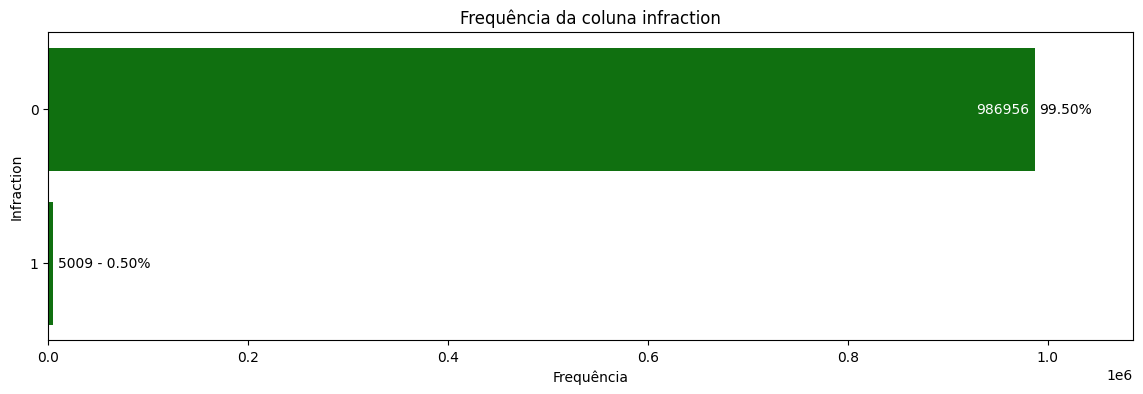

In [18]:
barplot(raw_transactions['infraction'])

Segmenting

In [19]:
print(raw_transactions['is_mei'].sum(), "merchants are MEI,", raw_transactions['is_legal_entity'].sum(),
      "merchants are legal entities and", raw_transactions['is_person'].sum(), "are person.")

171797 merchants are MEI, 386 merchants are legal entities and 808513 are person.


In [20]:
print(round(raw_transactions['is_mei'].sum() / raw_transactions.shape[0], 4) * 100, "% of merchants are MEI,",
      round(raw_transactions['is_legal_entity'].sum() / raw_transactions.shape[0], 4) * 100,
      "% of merchants are legal entities and",
      round(raw_transactions['is_person'].sum() / raw_transactions.shape[0], 4) * 100, "% are person.")

17.32 % of merchants are MEI, 0.04 % of merchants are legal entities and 81.51 % are person.


In [21]:
# Compute the percentage of fraudulent transactions per merchant.
fraud_percentage = raw_transactions.groupby('merchant_id')['infraction'].mean() * 100
# Optionally, convert to a DataFrame and sort
fraud_percentage_df = fraud_percentage.reset_index().rename(columns={'infraction': 'fraud_percentage'})
fraud_percentage_df = fraud_percentage_df.sort_values('fraud_percentage', ascending=False)
fraud_percentage_df

,merchant_id,fraud_percentage
53047,DGY3D9Z,100.0
101247,SSAV666,100.0
42478,D2S4ZVV,100.0
101231,SRY3UZ9,100.0
18410,CDCXU67,100.0
...,...,...
109343,ZZMQVTT,0.0
109344,ZZN3T3C,0.0
109345,ZZNQH9T,0.0
109346,ZZNRRK6,0.0


In [22]:
aux = fraud_percentage_df[fraud_percentage_df['fraud_percentage'] == 100.0]
aux['merchant_id'].nunique()

836

In [23]:
raw_transactions['merchant_id'].nunique()

109364

In [24]:
fraud_percentage_df['fraud_percentage'].describe()

count    109364.000000
mean          1.261091
std           9.997934
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         100.000000
Name: fraud_percentage, dtype: float64

Número de outliers (excluídos): 1983 (1.81% do total)
Número de registros considerados: 107381


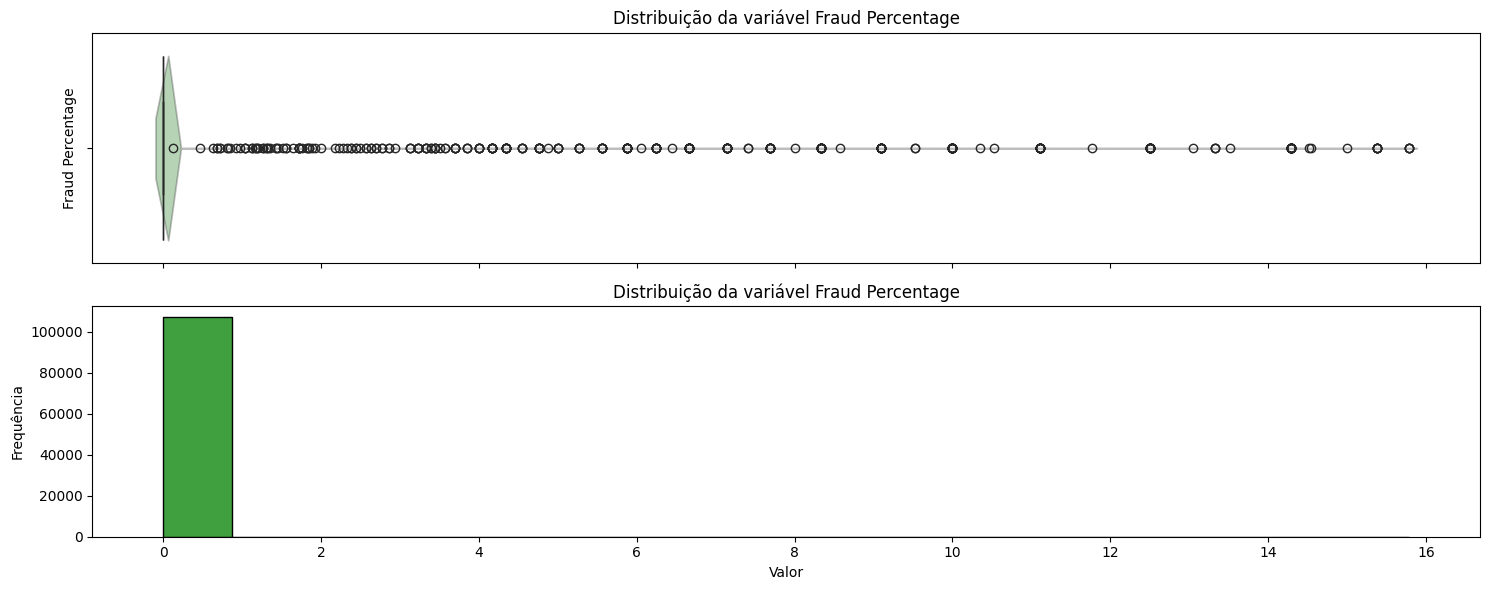

In [25]:
numeric_plot(fraud_percentage_df['fraud_percentage'])

### Time series analysis

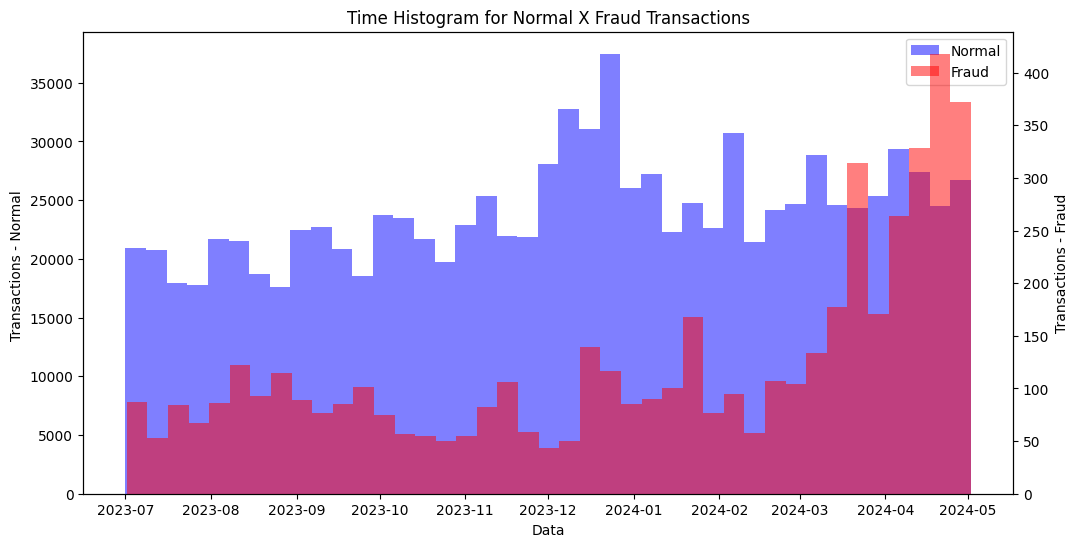

In [26]:
fig, ax1 = plt.subplots(figsize=(12, 6))

num_bins = 41  # semanas

# Histograma para a classe "Normal"
ax1.hist(raw_transactions.event_created_at[raw_transactions.infraction == 0], bins=num_bins, color='blue', alpha=0.5,
         label='Normal')

ax1.set_xlabel('Data')
ax1.set_ylabel('Transactions - Normal ')
ax1.set_title('Time Histogram for Normal X Fraud Transactions')

# Adiciona um segundo eixo y para a escala de "Fraude"
ax2 = ax1.twinx()
ax2.hist(raw_transactions.event_created_at[raw_transactions.infraction == 1], bins=num_bins, color='red', alpha=0.5,
         label='Fraud')

ax2.set_ylabel('Transactions - Fraud')

# Configuração da legenda
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

plt.show()

Número de missings: 0
Range da série: 01/Jul/2023 - 01/May/2024
	- 0Anos 10Meses 5dias


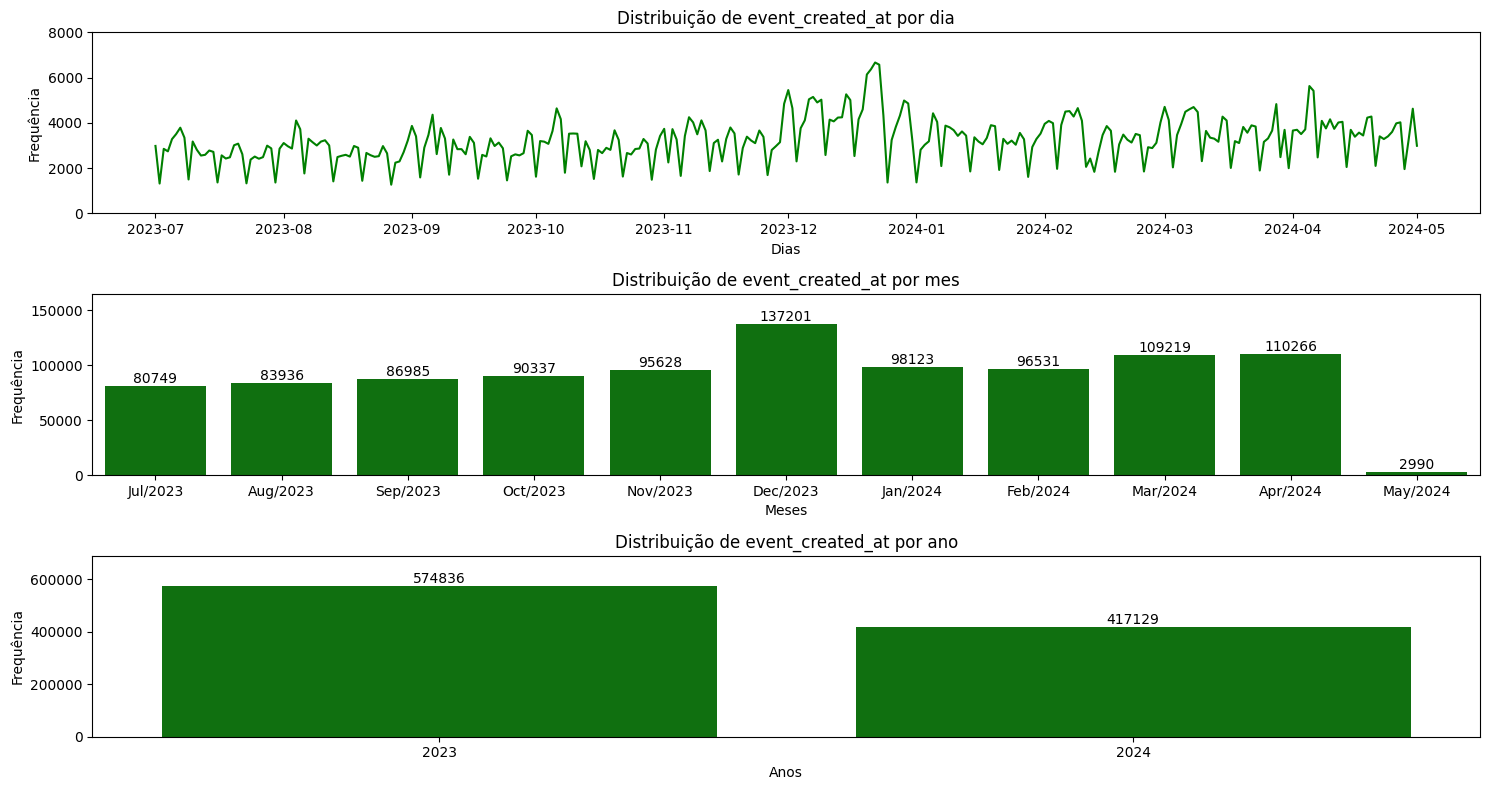



###################################################### Estatísticas ######################################################



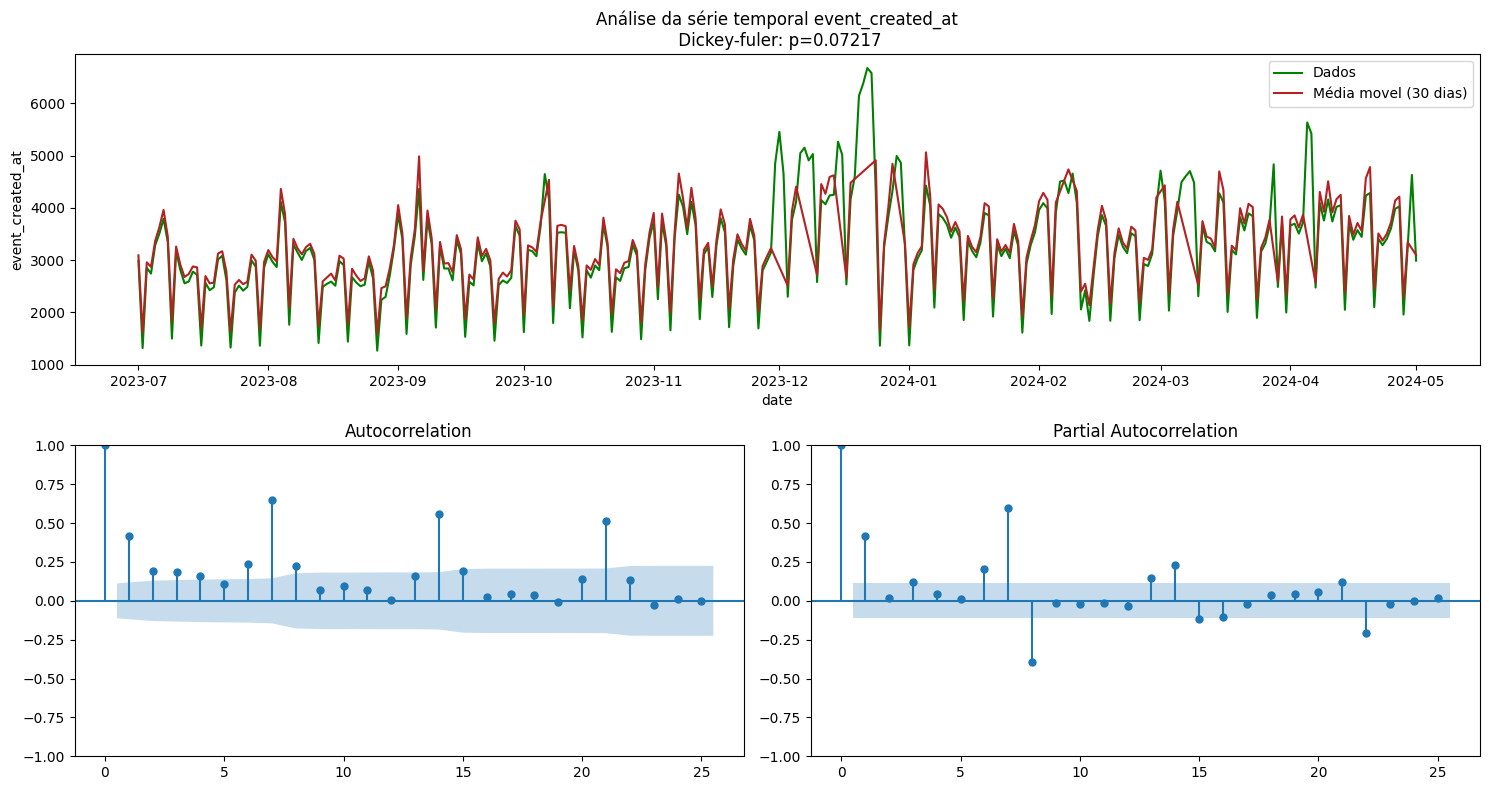

In [27]:
time_plot(raw_transactions['event_created_at'])

### Numerical

Número de outliers (excluídos): 20831 (2.1% do total)
Número de registros considerados: 971134


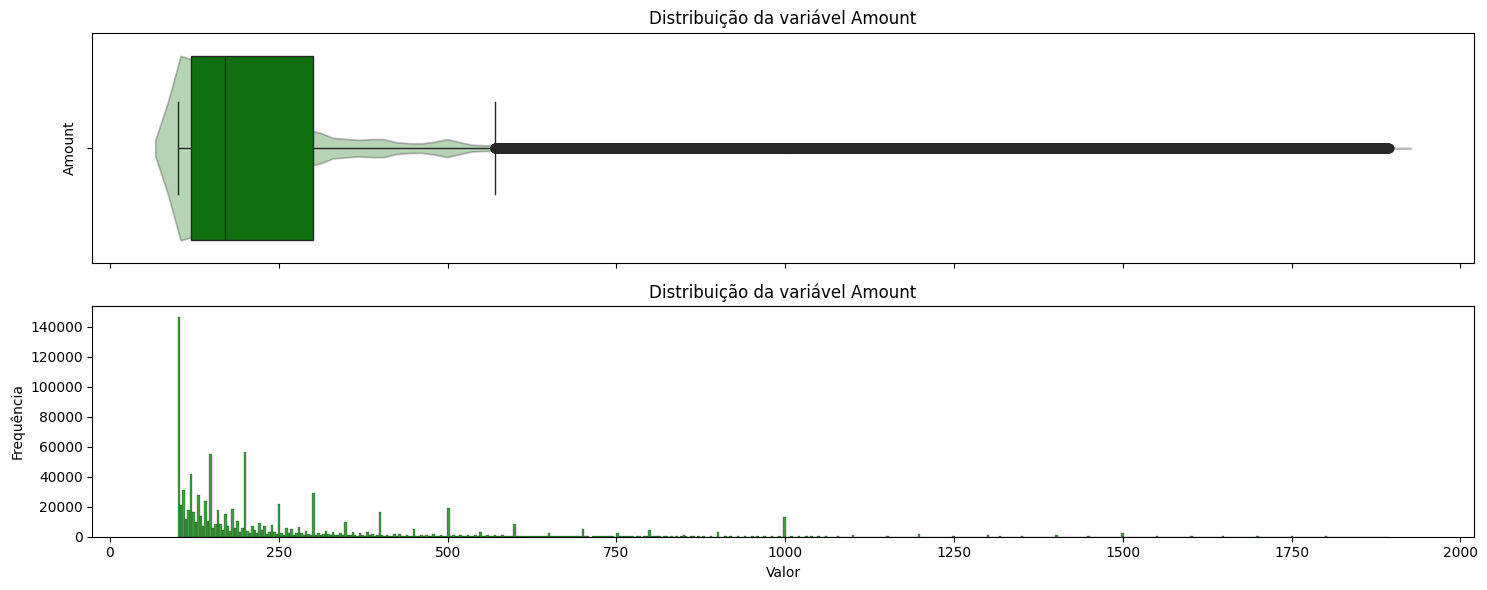

Número de outliers (excluídos): 17299 (1.74% do total)
Número de registros considerados: 974666


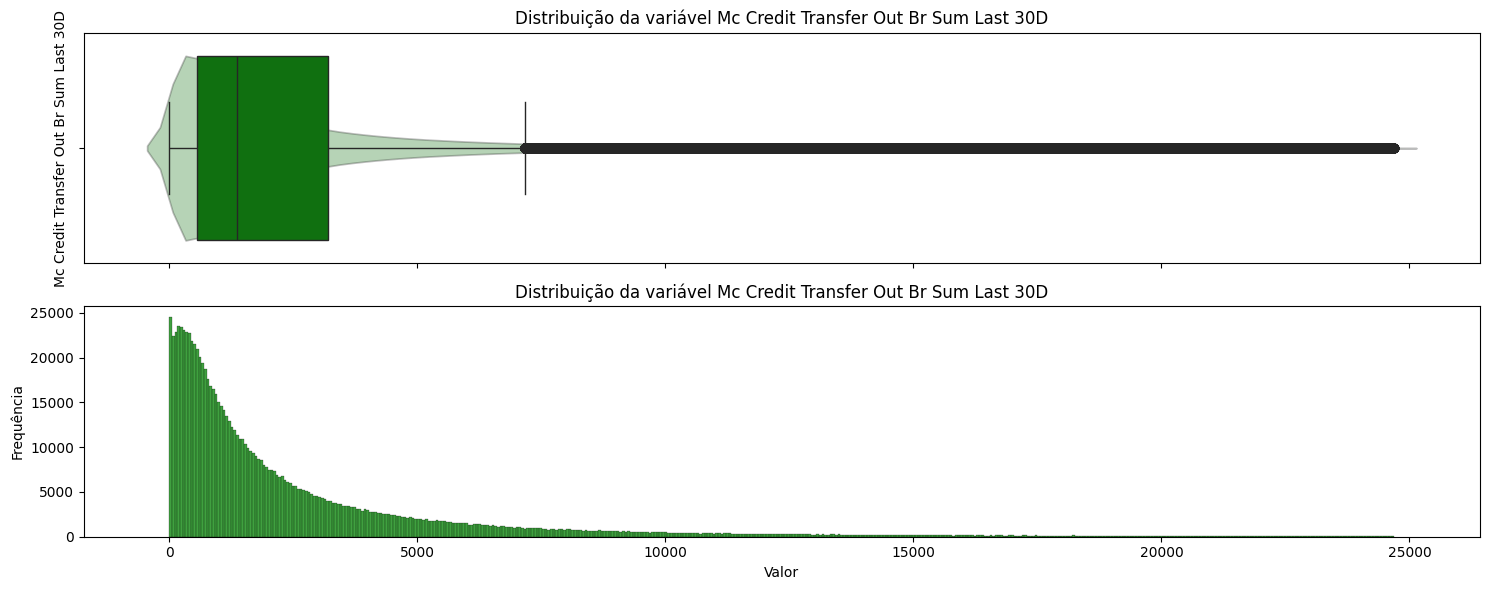

Número de outliers (excluídos): 13013 (1.31% do total)
Número de registros considerados: 978952


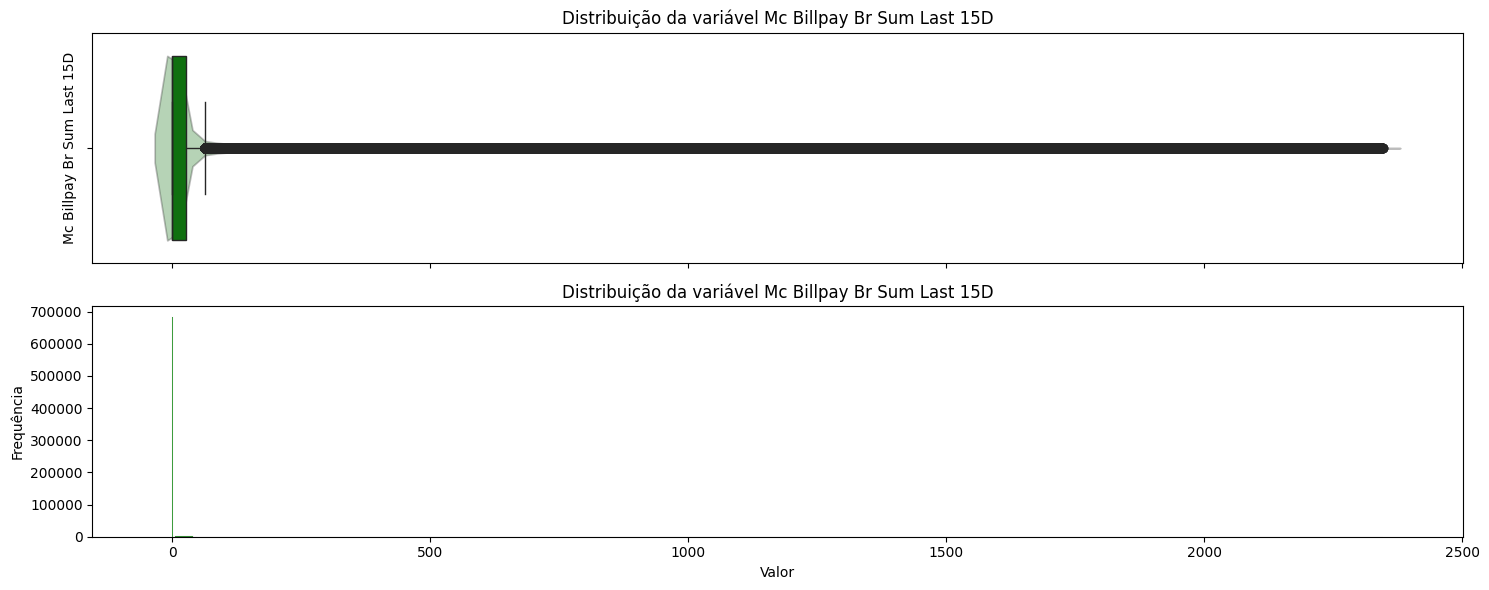

Número de outliers (excluídos): 44218 (4.46% do total)
Número de registros considerados: 947747


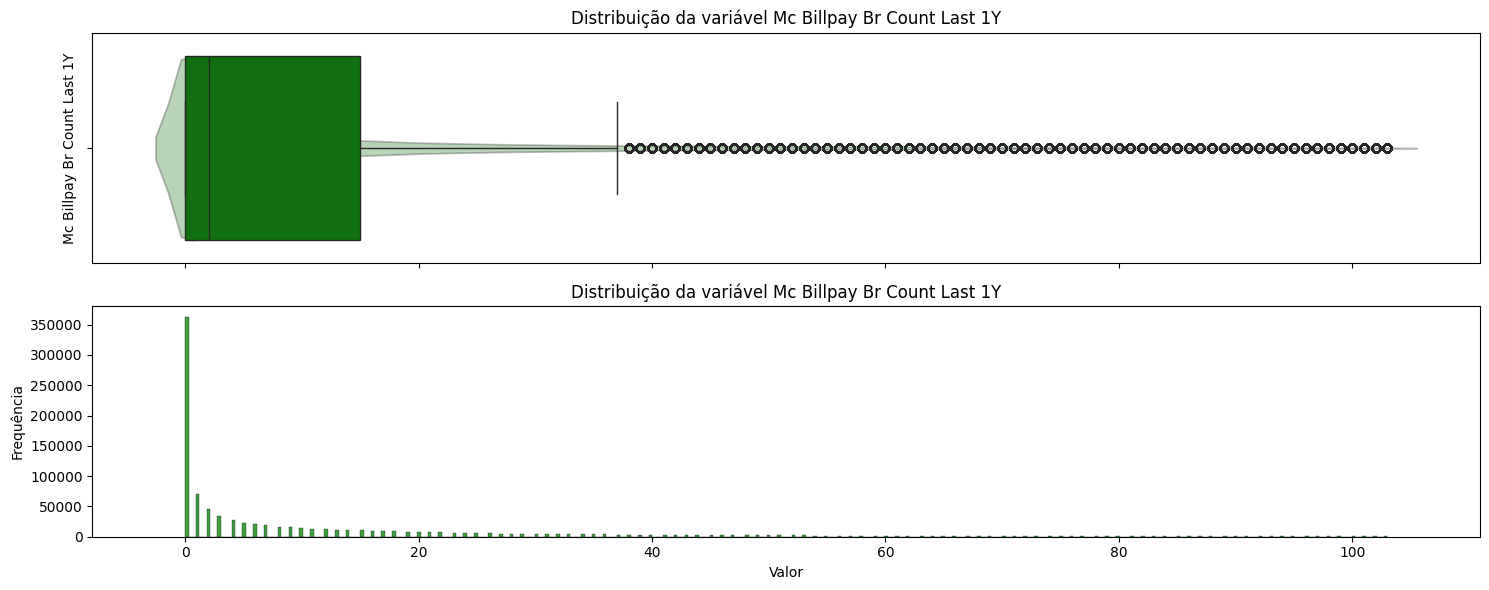

Número de outliers (excluídos): 25116 (2.53% do total)
Número de registros considerados: 966849


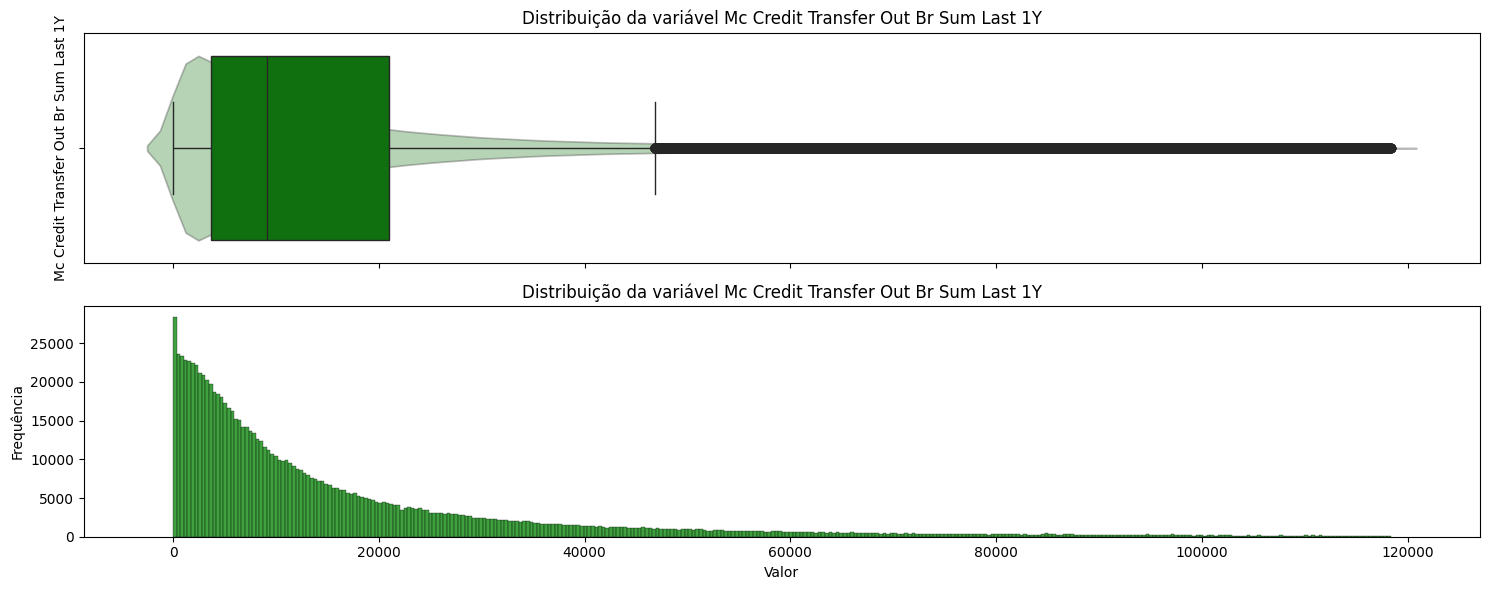

In [28]:
colunas_numericas = ['amount', 'mc_credit_transfer_out_br_sum_last_30d', 'mc_billpay_br_sum_last_15d',
                     'mc_billpay_br_count_last_1y', 'mc_credit_transfer_out_br_sum_last_1y',
                     # 'mc_tx_cp_dbt_sum_sq_fail_last_14d',
                     # 'mc_merchants_ip_count_dist_shared_last_15d',
                     # 'mcc_sum_succ_1y','mcc_sum_sq_succ_30d', 'mcc_count_succ_1y', 'mcc_sum_sq_succ_1y', 'mcc_sum_succ_30d'
                     ]
for colunas in colunas_numericas:
    numeric_plot(raw_transactions[colunas])

C:\Users\gabri\AppData\Local\Temp\ipykernel_13108\3047799008.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rates = df.groupby(cuts)['infraction'].mean()
C:\Users\gabri\AppData\Local\Temp\ipykernel_13108\3047799008.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_sizes = df.groupby(cuts).size()



Amount Statistics by Fraud Status:
               count         mean          std    min    25%    50%     75%  \
infraction                                                                    
0           986956.0   337.425147   766.679245  100.0  120.0  173.0   300.0   
1             5009.0  2856.989770  9368.572727  100.0  288.0  700.0  1950.0   

                 max  
infraction            
0           149850.0  
1           300000.0  

Correlation between amount and fraud: 0.1735

Fraud Rates by Amount Range:
        Amount Range  Fraud Rate (%)  Number of Transactions
0      100.00-120.00        0.130680                267064.0
1      120.00-175.00        0.142045                267520.0
2      175.00-300.00        0.292703                253841.0
3      300.00-638.00        0.643937                171290.0
4     638.00-1000.00        1.547051                 53198.0
5    1000.00-2986.00        2.120350                 49190.0
6  2986.00-300000.00        9.089993                

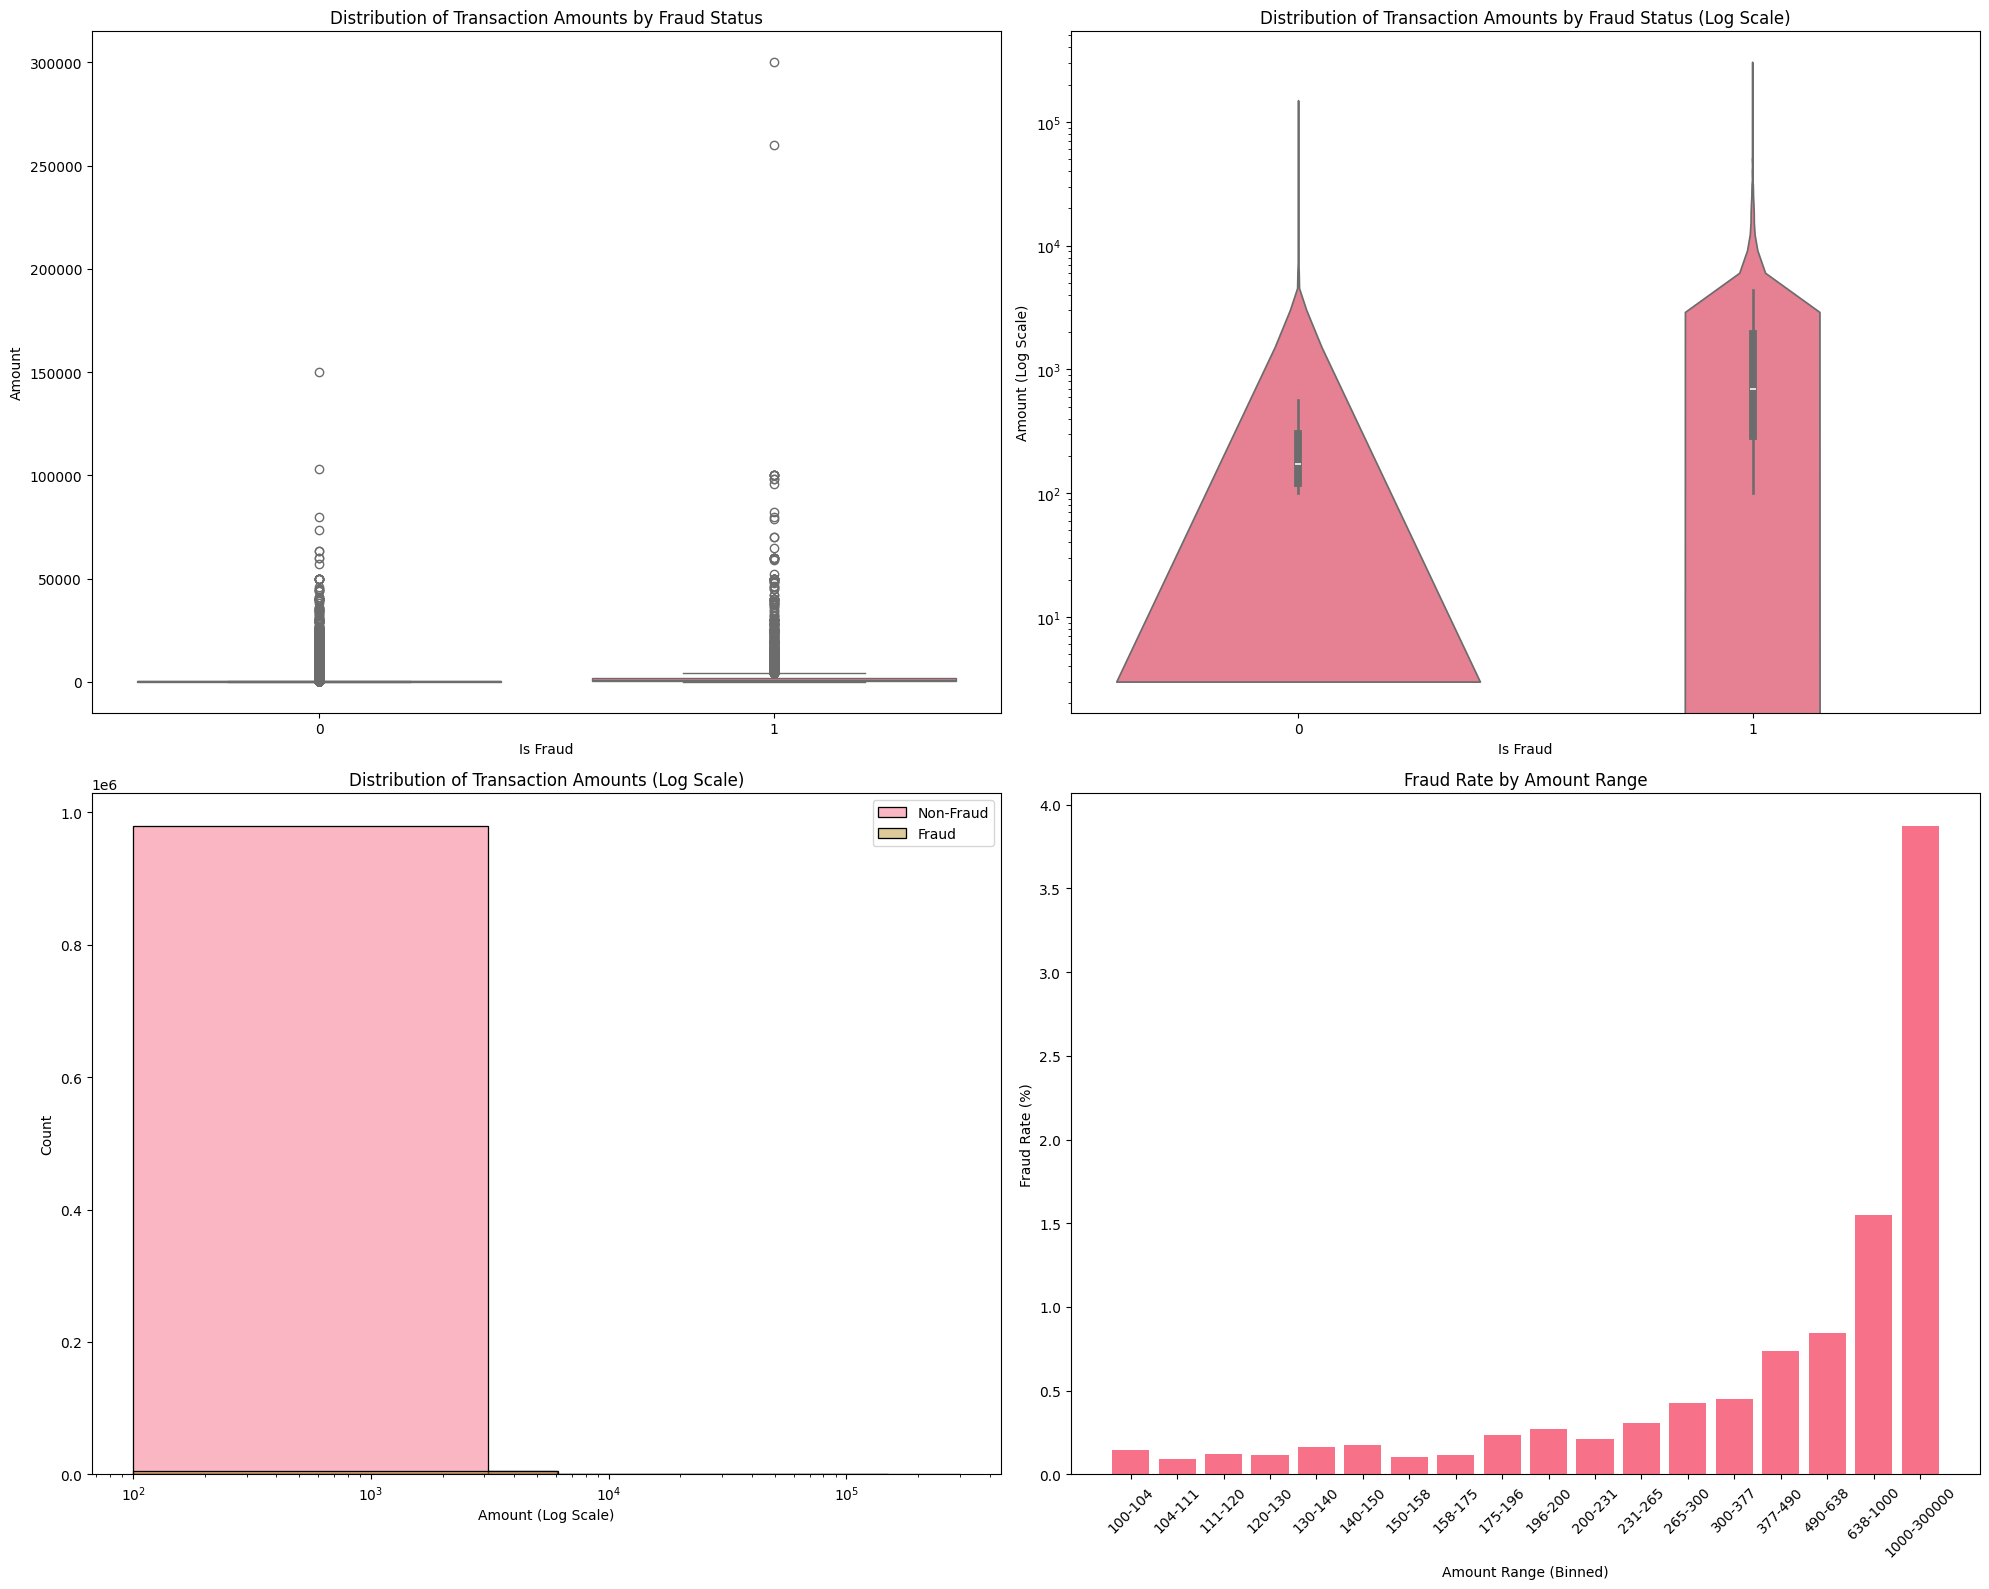

In [29]:
# Set style
sns.set_palette("husl")

# Create subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

# 1. Box plot of amount by fraud status
sns.boxplot(data=raw_transactions, x='infraction', y='amount', ax=ax1)
ax1.set_title('Distribution of Transaction Amounts by Fraud Status')
ax1.set_xlabel('Is Fraud')
ax1.set_ylabel('Amount')

# 2. Violin plot with log scale for better visualization
sns.violinplot(data=raw_transactions, x='infraction', y='amount', ax=ax2)
ax2.set_yscale('log')
ax2.set_title('Distribution of Transaction Amounts by Fraud Status (Log Scale)')
ax2.set_xlabel('Is Fraud')
ax2.set_ylabel('Amount (Log Scale)')

# 3. Histogram of amounts for fraudulent vs non-fraudulent transactions
sns.histplot(data=raw_transactions[raw_transactions['infraction'] == 0],
             x='amount', bins=50, alpha=0.5, ax=ax3, label='Non-Fraud')
sns.histplot(data=raw_transactions[raw_transactions['infraction'] == 1],
             x='amount', bins=50, alpha=0.5, ax=ax3, label='Fraud')
ax3.set_xscale('log')
ax3.set_title('Distribution of Transaction Amounts (Log Scale)')
ax3.set_xlabel('Amount (Log Scale)')
ax3.set_ylabel('Count')
ax3.legend()


# 4. Fraud rate by amount bins
def calculate_fraud_rate(df, column, bins=20):
    cuts = pd.qcut(df[column], q=bins, duplicates='drop')
    fraud_rates = df.groupby(cuts)['infraction'].mean()
    bin_sizes = df.groupby(cuts).size()
    return fraud_rates.index, fraud_rates.values, bin_sizes.values


bins, fraud_rates, bin_sizes = calculate_fraud_rate(raw_transactions, 'amount')
ax4.bar(range(len(bins)), fraud_rates * 100)
ax4.set_title('Fraud Rate by Amount Range')
ax4.set_xlabel('Amount Range (Binned)')
ax4.set_ylabel('Fraud Rate (%)')
ax4.set_xticks(range(len(bins)))
ax4.set_xticklabels([f'{b.left:.0f}-{b.right:.0f}' for b in bins], rotation=45)

# Adjust layout
plt.tight_layout()

# Calculate and print some statistics
fraud_stats = raw_transactions.groupby('infraction')['amount'].describe()
print("\nAmount Statistics by Fraud Status:")
print(fraud_stats)

# Calculate correlation
correlation = raw_transactions['amount'].corr(raw_transactions['infraction'])
print(f"\nCorrelation between amount and fraud: {correlation:.4f}")

# Calculate fraud rates for different amount ranges
percentiles = [0, 25, 50, 75, 90, 95, 99, 100]
amount_ranges = np.percentile(raw_transactions['amount'], percentiles)
fraud_by_range = pd.DataFrame()

for i in range(len(percentiles) - 1):
    mask = (raw_transactions['amount'] >= amount_ranges[i]) & (raw_transactions['amount'] <= amount_ranges[i + 1])
    subset = raw_transactions[mask]
    fraud_rate = (subset['infraction'] == 1).mean() * 100
    fraud_by_range.loc[i, 'Amount Range'] = f'{amount_ranges[i]:.2f}-{amount_ranges[i + 1]:.2f}'
    fraud_by_range.loc[i, 'Fraud Rate (%)'] = fraud_rate
    fraud_by_range.loc[i, 'Number of Transactions'] = len(subset)

print("\nFraud Rates by Amount Range:")
print(fraud_by_range)

plt.show()

### Correlation

In [30]:
raw_transactions_corr = raw_transactions.drop(columns=['event_created_at', 'merchant_id'])
raw_transactions_corr = raw_transactions_corr.drop(columns=list_variables_to_drop)
raw_transactions_corr.shape

(991965, 90)

In [51]:
# Compute the correlation matrices
corr_pearson = raw_transactions_corr.corr(method='pearson')
corr_kendall = raw_transactions_corr.corr(method='kendall')
corr_spearman = raw_transactions_corr.corr(method='spearman')


# Function to get the set of columns that appear in highly correlated pairs
def get_high_corr_cols(corr_matrix, threshold=0.95):
    high_corr = set()
    cols = corr_matrix.columns
    # Only check the upper triangle (excluding the diagonal)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr.add(cols[i])
                high_corr.add(cols[j])
    return high_corr


# Get high correlation column names for each method
high_corr_pearson = get_high_corr_cols(corr_pearson, threshold=0.99)
high_corr_kendall = get_high_corr_cols(corr_kendall, threshold=0.99)
high_corr_spearman = get_high_corr_cols(corr_spearman, threshold=0.99)

print("Columns with Pearson correlation >= 0.99:", high_corr_pearson)
print("Columns with Kendall correlation >= 0.99:", high_corr_kendall)
print("Columns with Spearman correlation >= 0.99:", high_corr_spearman)

Columns with Pearson correlation >= 0.99: {'mc_tx_cp_count_decl_ext_last_30d', 'mc_tx_amount_decl_ext_sum_lifetime', 'mc_credit_transfer_out_br_count_lifetime', 'mc_pur_br_count_last_1y', 'mc_tx_amount_fail_sum_last_60m', 'mc_atm_br_tx_out_count_lifetime', 'mc_pur_br_count_lifetime', 'mc_billpay_br_count_last_1y', 'mc_atm_br_tx_out_count_last_1y', 'mc_tx_count_decl_ext_last_30d', 'mc_tx_amount_fail_sum_lifetime', 'mc_credit_transfer_out_br_count_last_1y', 'mc_tx_amount_sum_last_60m', 'mc_billpay_br_count_lifetime', 'mc_tx_amount_sum_lifetime'}
Columns with Kendall correlation >= 0.99: set()
Columns with Spearman correlation >= 0.99: {'mc_tx_cp_count_decl_ext_last_24h', 'mc_tx_amount_succ_sum_last_60m', 'mc_credit_transfer_in_br_sum_last_120d', 'mc_credit_transfer_out_br_count_lifetime', 'mc_pur_br_count_last_1y', 'mc_tx_cp_sum_decl_ext_last_24h', 'mc_pur_br_count_lifetime', 'mc_billpay_br_count_last_1y', 'mc_credit_transfer_out_br_count_last_1y', 'mc_credit_transfer_in_br_sum_last_90d'

In [31]:
list_variables_to_drop += ['mc_chip_tx_amount_local_succ_sum_7d']
list_variables_to_drop

['mc_billpay_br_count_sanction_last_30d',
 'mc_pep_count_last_2d',
 'mc_billpay_br_count_pep_br_last_30d',
 'mc_credit_transfer_in_br_count_pep_br_last_30d',
 'mc_credit_transfer_out_br_count_pep_br_last_30d',
 'mc_tx_amount_pend_sum_last_14d',
 'mc_chip_tx_amount_local_succ_sum_7d']

In [55]:
correlations = raw_transactions_corr.corr(method='pearson')['infraction'].sort_values(ascending=False)
correlations

infraction                               1.000000
amount                                   0.173474
mc_atm_br_tx_out_count_last_15d          0.096659
mc_credit_transfer_in_br_sum_last_15d    0.056832
is_mei                                   0.023547
                                           ...   
mcc_sum_sq_succ_30d                     -0.044784
mcc_sum_sq_succ_1y                      -0.046114
mcc_sum_succ_30d                        -0.052541
mcc_sum_succ_1y                         -0.054380
mc_weeks_signup                         -0.085331
Name: infraction, Length: 89, dtype: float64


In [52]:
# Assuming df is your DataFrame after dropping unwanted columns
correlations = raw_transactions_corr.corr(method='kendall')['infraction'].sort_values(ascending=False)
correlations

infraction                            1.000000
mc_atm_br_tx_out_count_last_15d       0.067156
amount                                0.060816
mc_atm_br_tx_out_count_last_1y        0.034889
mc_atm_br_tx_out_count_lifetime       0.033916
                                        ...   
mc_tx_amount_decl_ext_sum_lifetime   -0.080070
mc_tx_succ_count_last_365d           -0.083221
mc_tx_amount_sum_lifetime            -0.083375
mc_tx_amount_succ_sum_lifetime       -0.087874
mc_tx_succ_count_lifetime            -0.088719
Name: infraction, Length: 89, dtype: float64


In [53]:
# Assuming df is your DataFrame after dropping unwanted columns
correlations = raw_transactions_corr.corr(method='spearman')['infraction'].sort_values(ascending=False)
correlations

infraction                            1.000000
amount                                0.073449
mc_atm_br_tx_out_count_last_15d       0.067568
mc_atm_br_tx_out_count_last_1y        0.035790
mc_atm_br_tx_out_count_lifetime       0.034817
                                        ...   
mc_tx_amount_decl_ext_sum_lifetime   -0.097922
mc_tx_succ_count_last_365d           -0.101660
mc_tx_amount_sum_lifetime            -0.102098
mc_tx_amount_succ_sum_lifetime       -0.107597
mc_tx_succ_count_lifetime            -0.108596
Name: infraction, Length: 89, dtype: float64


In [54]:
from scipy import stats

# Calculate correlation and p-value for each feature
correlations, p_values = {}, {}
for col in raw_transactions_corr.columns.to_list():  # Replace with your feature list
    corr, p_val = stats.pointbiserialr(raw_transactions_corr[col], raw_transactions_corr['infraction'])
    correlations[col] = corr
    p_values[col] = p_val

# Display results sorted by absolute correlation
corr_df = pd.DataFrame({'Feature': correlations.keys(),
                        'Correlation': correlations.values(),
                        'p-value': p_values.values()})
corr_df = corr_df.sort_values(by='Correlation', key=abs, ascending=False)
corr_df

,Feature,Correlation,p-value
1,infraction,1.000000,0.0
0,amount,0.173474,0.0
81,mcc_sum_succ_1y,-0.054380,0.0
85,mcc_sum_succ_30d,-0.052541,0.0
84,mcc_sum_sq_succ_1y,-0.046114,0.0
...,...,...,...
30,mc_atm_br_tx_out_count_last_15d,NaN,NaN
32,mc_credit_transfer_in_br_sum_last_60d,NaN,NaN
33,mc_pur_br_sum_last_1y,NaN,NaN
43,mc_tx_cp_mean_decl_ext_last_31d_mw,NaN,NaN


In [ ]:
# list_variables_to_drop += ['<adicionar>']
# list_variables_to_drop

In [32]:
# Drop the columns from raw_transactions
raw_transactions = raw_transactions.drop(columns=list_variables_to_drop)
raw_transactions.to_csv("raw_transactions.csv", index=False)
raw_transactions.shape
# (991.965, 91)

(991965, 91)

## Fraud by merchant type

### Fraud rate per category

### Prevalence of fraud per category

In [33]:
# Total fraudulent transactions
total_fraud = raw_transactions['infraction'].sum()

fraud_rates = {}
for col in ['is_legal_entity', 'is_mei', 'is_person']:
    fraud_count = raw_transactions[raw_transactions[col] == 1]['infraction'].sum()
    total_transactions = raw_transactions[col].sum()
    fraud_rate = (fraud_count / total_transactions) * 100 if total_transactions > 0 else 0
    fraud_rates[col] = fraud_rate

fraud_rates

{'is_legal_entity': np.float64(0.0),
 'is_mei': np.float64(0.8696310180038068),
 'is_person': np.float64(0.4200303520166033)}

In [34]:
fraud_distribution = {}
for col in ['is_legal_entity', 'is_mei', 'is_person']:
    fraud_distribution[col] = (raw_transactions[raw_transactions[col] == 1]['infraction'].sum() / total_fraud) * 100

fraud_distribution

{'is_legal_entity': np.float64(0.0),
 'is_mei': np.float64(29.826312637252943),
 'is_person': np.float64(67.79796366540228)}

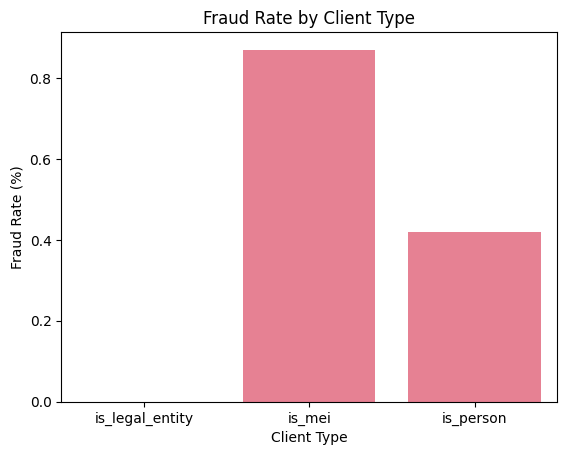

In [35]:
sns.barplot(x=list(fraud_rates.keys()), y=list(fraud_rates.values()))
plt.title("Fraud Rate by Client Type")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Client Type")
plt.show()

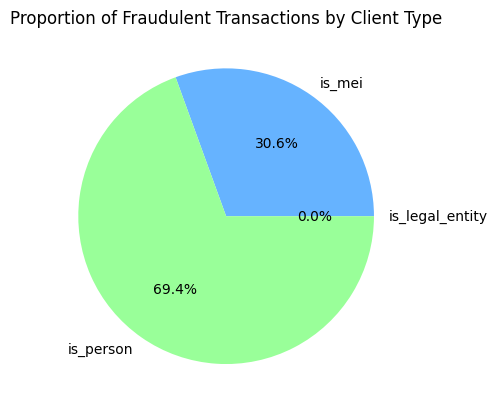

In [36]:
plt.pie(
    list(fraud_distribution.values()),
    labels=list(fraud_distribution.keys()),
    autopct='%1.1f%%',
    colors=['#ff9999', '#66b3ff', '#99ff99']
)
plt.title("Proportion of Fraudulent Transactions by Client Type")
plt.show()

In [39]:
overall = raw_transactions[['is_legal_entity', 'is_mei', 'is_person']].mean()
print("Overall distribution:")
overall

Overall distribution:


is_legal_entity    0.000389
is_mei             0.173189
is_person          0.815062
dtype: float64

In [40]:
fraud = raw_transactions[raw_transactions['infraction'] == 1][['is_legal_entity', 'is_mei', 'is_person']].mean()
print("Fraudulent transactions distribution:")
fraud

Fraudulent transactions distribution:


is_legal_entity    0.000000
is_mei             0.298263
is_person          0.677980
dtype: float64

In [41]:
# Calculate overall distribution (proportion of 1's)
overall_distribution = raw_transactions[['is_legal_entity', 'is_mei', 'is_person']].mean()

# Calculate distribution among fraudulent transactions
fraud_distribution = raw_transactions[raw_transactions['infraction'] == 1][
    ['is_legal_entity', 'is_mei', 'is_person']].mean()

# Optional: Create a DataFrame to compare them side by side
comparison = pd.DataFrame({
    'Overall': overall_distribution,
    'Fraudulent': fraud_distribution
})
print("\nComparison of Overall vs Fraudulent Distributions:")
comparison


Comparison of Overall vs Fraudulent Distributions:


,Overall,Fraudulent
is_legal_entity,0.000389,0.000000
is_mei,0.173189,0.298263
is_person,0.815062,0.677980


In [42]:
# Calculate fraud/non-fraud percentages for each client type
client_types = ['is_legal_entity', 'is_mei', 'is_person']
fraud_data = []

for col in client_types:
    # Total transactions for the client type
    total = raw_transactions[col].sum()
    if total == 0:
        continue  # Skip if no transactions

    # Fraudulent transactions for the client type
    fraud = raw_transactions[(raw_transactions[col] == 1) & (raw_transactions['infraction'] == 1)].shape[0]
    fraud_pct = (fraud / total) * 100
    non_fraud_pct = 100 - fraud_pct

    fraud_data.append({
        'ClientType': col.replace('is_', '').replace('_', ' ').title(),
        'Fraud (%)': fraud_pct,
        'Non-Fraud (%)': non_fraud_pct
    })

# Create a DataFrame for plotting
plot_df = pd.DataFrame(fraud_data)
plot_df = plot_df.melt(id_vars='ClientType', var_name='Category', value_name='Percentage')

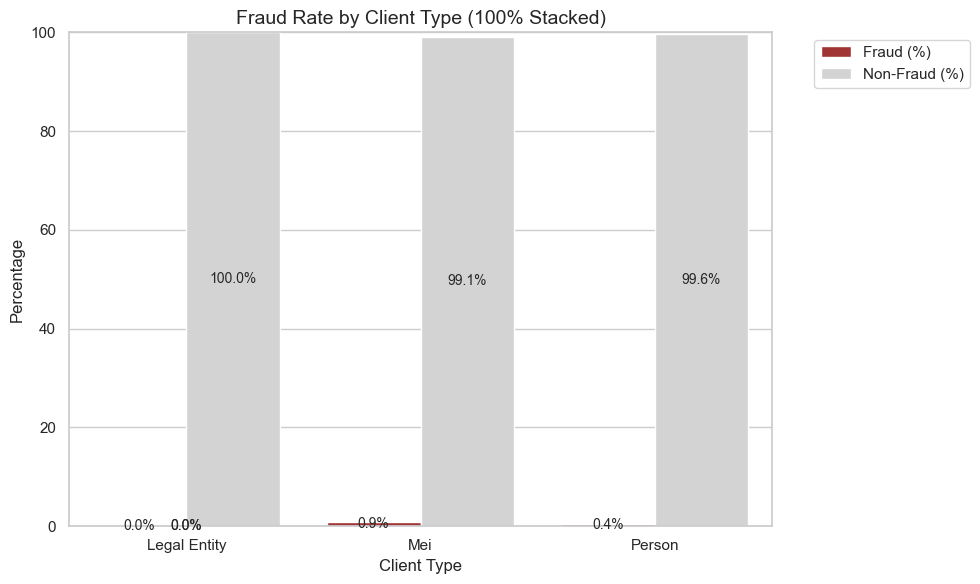

In [43]:
# Create the plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Use Seaborn to create a bar plot with hue (split into Fraud/Non-Fraud)
ax = sns.barplot(
    x='ClientType',
    y='Percentage',
    hue='Category',
    data=plot_df,
    palette={'Fraud (%)': 'firebrick', 'Non-Fraud (%)': 'lightgrey'}
)

# Customize labels and titles
plt.title('Fraud Rate by Client Type (100% Stacked)', fontsize=14)
plt.xlabel('Client Type', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.ylim(0, 100)  # Ensure y-axis spans 0-100%

# Add percentage labels
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.annotate(
        f'{height:.1f}%',
        (x + width / 2, y + height / 2),
        ha='center',
        va='center',
        fontsize=10
    )

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Outliers and standarization

In [45]:
# Example outlier treatment functions

def outlier_zscore(X, threshold=3):
    # For each numeric column, clip values that are more than threshold standard deviations away from the mean.
    def clip_z(s):
        if np.issubdtype(s.dtype, np.number):
            return s.clip(s.mean() - threshold * s.std(), s.mean() + threshold * s.std())
        else:
            return s

    return X.apply(clip_z)


def outlier_iqr(X):
    # For each numeric column, clip values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    def clip_iqr(s):
        if np.issubdtype(s.dtype, np.number):
            Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
            IQR = Q3 - Q1
            lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
            return s.clip(lower, upper)
        else:
            return s

    return X.apply(clip_iqr)


def outlier_clip(X):
    # For each numeric column, clip to the 1st and 99th percentiles.
    def clip_percentile(s):
        if np.issubdtype(s.dtype, np.number):
            lower, upper = s.quantile(0.01), s.quantile(0.99)
            return s.clip(lower, upper)
        else:
            return s

    return X.apply(clip_percentile)


def outlier_winsorize(X):
    # Winsorize each numeric column by limiting the lower and upper 1% of values.
    def winsorize_series(s):
        if np.issubdtype(s.dtype, np.number):
            return pd.Series(mstats.winsorize(s, limits=[0.02, 0.02]), index=s.index)
        else:
            return s

    return X.apply(winsorize_series)


# Dictionary mapping method names to functions
outlier_methods = {
    'zscore': outlier_zscore,
    'iqr': outlier_iqr,
    'clip': outlier_clip,
    'winsorize': outlier_winsorize
}

# Normalization methods
norm_methods = {
    'standard': StandardScaler(),
    'minmax': MinMaxScaler(),
    'robust': RobustScaler()
}

# Assume your cleaned DataFrame is raw_transactions.
# Your target is 'infraction' (0=legit, 1=fraud).
# Remove non-feature columns: 'infraction', 'event_created_at', and 'merchant_id'.
features = raw_transactions.drop(columns=['infraction', 'event_created_at', 'merchant_id'])
target = raw_transactions['infraction']

# Split the data (stratified to preserve class distribution)
X_train, X_test, y_train, y_test = train_test_split(features, target, stratify=target, random_state=42)

# Prepare to collect evaluation metrics
results = []

# Loop over each combination of outlier and normalization method.
for outlier_name, outlier_func in outlier_methods.items():
    # Apply the outlier treatment on the training and testing sets.
    X_train_out = outlier_func(X_train.copy())
    X_test_out = outlier_func(X_test.copy())

    for norm_name, scaler in norm_methods.items():
        # Copy the data for normalization.
        X_train_norm = X_train_out.copy()
        X_test_norm = X_test_out.copy()

        # Identify numeric columns and scale them.
        numeric_cols = X_train_norm.select_dtypes(include=[np.number]).columns
        X_train_norm[numeric_cols] = scaler.fit_transform(X_train_norm[numeric_cols])
        X_test_norm[numeric_cols] = scaler.transform(X_test_norm[numeric_cols])

        # Train an XGBoost classifier.
        model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
        model.fit(X_train_norm, y_train)
        y_pred = model.predict(X_test_norm)

        # Evaluate accuracy, precision, and recall.
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        # Compute precision@100.
        # Get predicted probabilities for the positive class.
        y_proba = model.predict_proba(X_test_norm)[:, 1]
        # Get indices of the top 100 predictions (highest fraud probability).
        top_100_indices = np.argsort(y_proba)[::-1][:100]
        # Calculate precision@100 as the proportion of true frauds in the top 100.
        precision_at_100 = y_test.iloc[top_100_indices].sum() / 100.0

        results.append({
            'Outlier': outlier_name,
            'Normalization': norm_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
            'Precision@100': precision_at_100
        })

# Create a DataFrame with the results and display it.
results_df = pd.DataFrame(results)
results_df.to_csv('oulier_standarization_analysis.csv', index=False)
results_df

C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [01:31:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [01:32:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [01:32:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg,

,Outlier,Normalization,Accuracy,Precision,Recall,F1,Precision@100
0,zscore,standard,0.996085,0.699858,0.392971,0.503325,0.86
1,zscore,minmax,0.996052,0.704648,0.375399,0.489838,0.89
2,zscore,robust,0.995996,0.690162,0.375399,0.486291,0.90
3,iqr,standard,0.996016,0.677898,0.401757,0.504514,0.83
4,iqr,minmax,0.996036,0.673997,0.416134,0.514568,0.87
5,iqr,robust,0.996097,0.689840,0.412141,0.516000,0.92
6,clip,standard,0.996197,0.700389,0.431310,0.533861,0.87
7,clip,minmax,0.996133,0.696118,0.415335,0.520260,0.85
8,clip,robust,0.996177,0.700000,0.424920,0.528827,0.89
9,winsorize,standard,0.996093,0.692517,0.406550,0.512330,0.87


(clip, minmax) winner!
0.996238  0.700629  0.444888  0.544211

In [46]:
# Baseline experiment: No outlier treatment and no normalization.
X_train_base = X_train.copy()
X_test_base = X_test.copy()

model_base = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_base.fit(X_train_base, y_train)
y_pred_base = model_base.predict(X_test_base)

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base, zero_division=0)
rec_base = recall_score(y_test, y_pred_base, zero_division=0)
f1_base = f1_score(y_test, y_pred_base, zero_division=0)

# Compute precision@100.
# Get predicted probabilities for the positive class.
y_proba = model.predict_proba(X_test_norm)[:, 1]
# Get indices of the top 100 predictions (highest fraud probability).
top_100_indices = np.argsort(y_proba)[::-1][:100]
# Calculate precision@100 as the proportion of true frauds in the top 100.
precision_at_100_base = y_test.iloc[top_100_indices].sum() / 100.0

results.append({
    'Outlier': 'None',
    'Normalization': 'None',
    'Accuracy': acc_base,
    'Precision': prec_base,
    'Recall': rec_base,
    'F1': f1_base,
    'Precision@100': precision_at_100_base
})

# Create a DataFrame with the results and display it.
results_df = pd.DataFrame(results)
results_df

C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [01:35:08] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Outlier,Normalization,Accuracy,Precision,Recall,F1,Precision@100
0,zscore,standard,0.996085,0.699858,0.392971,0.503325,0.86
1,zscore,minmax,0.996052,0.704648,0.375399,0.489838,0.89
2,zscore,robust,0.995996,0.690162,0.375399,0.486291,0.90
3,iqr,standard,0.996016,0.677898,0.401757,0.504514,0.83
4,iqr,minmax,0.996036,0.673997,0.416134,0.514568,0.87
5,iqr,robust,0.996097,0.689840,0.412141,0.516000,0.92
6,clip,standard,0.996197,0.700389,0.431310,0.533861,0.87
7,clip,minmax,0.996133,0.696118,0.415335,0.520260,0.85
8,clip,robust,0.996177,0.700000,0.424920,0.528827,0.89
9,winsorize,standard,0.996093,0.692517,0.406550,0.512330,0.87


In [47]:
fraudulent_transactions = raw_transactions[raw_transactions['infraction'] == 1].reset_index(drop=True)
normal_transactions = raw_transactions[raw_transactions['infraction'] == 0].reset_index(drop=True)

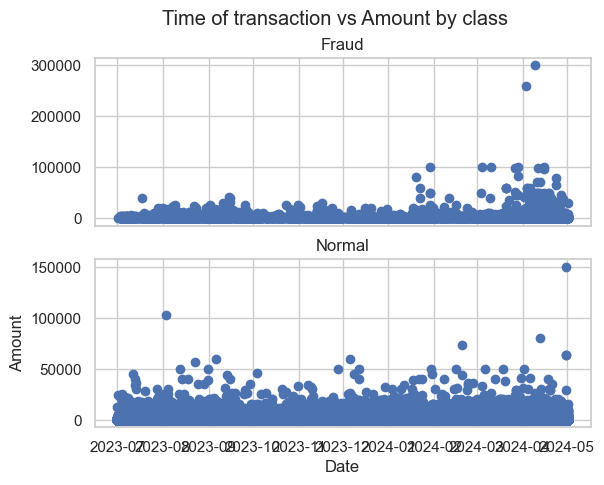

In [48]:
# We Will check Do fraudulent transactions occur more often during certain time frame ? Let us find out with a visual representation.

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Time of transaction vs Amount by class')
ax1.scatter(fraudulent_transactions.event_created_at, fraudulent_transactions.amount)
ax1.set_title('Fraud')
ax2.scatter(normal_transactions.event_created_at, normal_transactions.amount)
ax2.set_title('Normal')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.show()